# Module 2: annotation

Annotation of metabolomics data is often based on matching measured parameters to those of authentic compounds. This includes m/z, retention time in LC-MS or GC-MS, and fragment patterns in MS/MS. Additional parameters can be useful, e.g., CCS from ion mobility spectrometry. 

This notebook illustrates the principles of LC-MS and MS/MS data annotation. Please refer to Asari documentation for produciton use. 


In [9]:
# 1 - library setup
import os
import pickle
import json
import tqdm
import numpy as np
import pprint
import pandas as pd
import matplotlib.pyplot as plt

from datetime import date
from asari.tools.ms2 import extract_all_spectra_form_file
from asari.tools.file_io import read_features_from_asari_table
from asari.tools import match_features as mf

from asari.tools.cosine import cosine_similarity
from asari.tools.plot import mirror_plot
from asari.tools.msp_parser import MSP_dict, parse_msp_to_listdict, msp_standarize



In addition to the `MT02` dataset, we use `Anno_data_202707.zip` from https://github.com/shuzhao-li-lab/data/raw/main/data/Anno_data_202707.zip .
This contains 
- ID_01.mzML, a DDA file containing MS/MS spectra
- MSMS-Pos-MassBank.msp, a typical MS/MS database file	
- v3_authlib2024_hilicpos.json, a library of authentic compound from the Li lab

## Annotation using authentic compound library (MS1)

Do not use `mf.bidirectional_best_match` in production, wrong heuristics for chaining evidence. 



## MS/MS Annotation

Let's use MONA msp here. No pickle, no entropy_search - basic cosine similarity. 

Use as little custom code as possible for simplicity. 



In [1]:
this_dir = '../example_data/Anno_data/'


In [6]:
# look at msp database file

massbank = msp_standarize(parse_msp_to_listdict(
    os.path.join(this_dir, 'MSMS-Pos-MassBank.msp')
    ), MSP_dict)

# show example
massbank[0]

{'NAME': 'Veratramine; LC-ESI-TOF; MS2; CE',
 'PRECURSORMZ': '410.305356',
 'PRECURSORTYPE': '[M+H]+',
 'FORMULA': 'C27H39NO2',
 'Ontology': 'Fluorenes',
 'INCHIKEY': 'MALFODICFSIXPO-KFKQDBFTSA-N',
 'SMILES': 'C[C@H]([C@@H]1NC[C@@H](C)C[C@H]1O)C1=C(C)C2=C(C=C1)[C@@H]1CC=C3C[C@@H](O)CC[C@]3(C)[C@H]1C2',
 'RETENTIONTIME': '',
 'CCS': '207.3842046',
 'IONMODE': 'Positive',
 'INSTRUMENTTYPE': 'LC-ESI-QTOF',
 'INSTRUMENT': '',
 'COLLISIONENERGY': '',
 'Comment': 'registered in MassBank',
 'Num Peaks': '83',
 'peaks': [(84.1, 32.0),
  (105.1, 6.0),
  (107.1, 6.0),
  (114.1, 105.0),
  (115.1, 7.0),
  (119.1, 8.0),
  (121.1, 6.0),
  (124.1, 83.0),
  (125.1, 8.0),
  (129.10001, 7.0),
  (131.10001, 129.0),
  (132.10001, 13.0),
  (133.10001, 212.0),
  (134.10001, 23.0),
  (144.10001, 5.0),
  (145.10001, 108.0),
  (146.10001, 12.0),
  (147.10001, 14.0),
  (151.10001, 8.0),
  (155.10001, 26.0),
  (156.10001, 17.0),
  (157.10001, 372.0),
  (158.10001, 45.0),
  (159.10001, 216.0),
  (160.10001, 29.0)

In [10]:
# Read MS/MS file

[ms1_spectra, ms2_spectra, others] = extract_all_spectra_form_file(
        os.path.join(this_dir, 'ID_01.mzML')
    )

with open(
    os.path.join(this_dir, "ID_01_MS2.json"), "w"
) as O:
    json.dump(ms2_spectra, O)
 

term not found (MS:1000026)
term not found (MS:1000026)
term not found (MS:1000026)
term not found (MS:1000026)


In [11]:
our_ms2 = json.load(open(os.path.join(this_dir, "ID_01_MS2.json")))
our_ms2[0]

{'id': 'sp3',
 'precursor_mz': 214.987487792969,
 'rtime': 0.3385186399999998,
 'peaks': [[150.96871948242188, 162493],
  [72.93687438964844, 121631],
  [132.95811462402344, 108013],
  [191.9716033935547, 64118],
  [155.97413635253906, 57564],
  [173.9846954345703, 49743],
  [90.94745635986328, 49478],
  [113.96346282958984, 40465],
  [70.95758819580078, 24763],
  [197.0009002685547, 18890],
  [149.9607696533203, 13629],
  [209.98231506347656, 11765],
  [111.98410034179688, 8452],
  [55.9342041015625, 8411],
  [167.9715576171875, 7583],
  [91.90328979492188, 7071],
  [131.97401428222656, 7005],
  [154.99029541015625, 6903],
  [108.9580078125, 6778],
  [168.97915649414062, 6744],
  [172.97703552246094, 6354],
  [90.90292358398438, 6235],
  [132.9299774169922, 4377],
  [173.96128845214844, 4338],
  [149.94049072265625, 3264],
  [61.69279479980469, 2885],
  [72.5853500366211, 2741],
  [68.94639587402344, 2598],
  [87.19596862792969, 2478],
  [67.78878021240234, 2460],
  [72.06359100341797

In [27]:
# a subset of MS/MS database search
# Known good matches 168.0654296875 168.06552

our_ms2_selected = [x for x in our_ms2 if int(x['precursor_mz']) == 168]
db_ms2_selected= [x for x in massbank if int(float(x['PRECURSORMZ'])) == 168]
len(our_ms2_selected), len(db_ms2_selected)

(4, 5)

In [ ]:
cpd_ms2_scores = []
for x in our_ms2_selected:
    _scores = [round(float(cosine_similarity(x['peaks'], spec2['peaks'], mz_tolerance=0.01)[0]), 3) for spec2 in db_ms2_selected]
    print(_scores)
    cpd_ms2_scores.append(_scores)


[0.0, 0.0, 0.0, 0.006, 0.989]
[0.0, 0.0, 0.0, 0.0, 0.961]
[0.0, 0.0, 0.0, 0.006, 0.824]
[0.0, 0.0, 0.0, 0.0, 0.856]


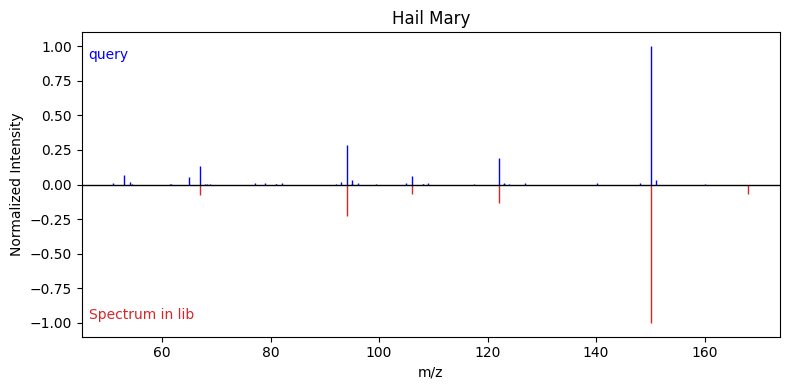

In [29]:
# db_ms2_selected[4] best match to our_ms2_selected[0]

mirror_plot(
    our_ms2_selected[0]['peaks'], 
    db_ms2_selected[4]['peaks'], 
    label1="query",
    label2="Spectrum in lib",
    title="Hail Mary",
    outfile=None
)

In [30]:
db_ms2_selected[4]

{'NAME': 'Pyridoxal; LC-ESI-QTOF; MS2; CE',
 'PRECURSORMZ': '168.06552',
 'PRECURSORTYPE': '[M+H]+',
 'FORMULA': 'C8H9NO3',
 'Ontology': 'Pyridoxals and derivatives',
 'INCHIKEY': 'RADKZDMFGJYCBB-UHFFFAOYSA-N',
 'SMILES': 'CC1=C(O)C(C=O)=C(CO)C=N1',
 'RETENTIONTIME': '',
 'CCS': '135.5965362',
 'IONMODE': 'Positive',
 'INSTRUMENTTYPE': 'LC-ESI-QTOF',
 'INSTRUMENT': '',
 'COLLISIONENERGY': '',
 'Comment': 'registered in MassBank',
 'Num Peaks': '6',
 'peaks': [(67.0546, 73.0),
  (94.0652, 225.0),
  (106.0655, 67.0),
  (122.0609, 136.0),
  (150.05431, 1000.0),
  (168.06599, 66.0)]}

**Skip MS/MS matching feature table**

**Skip combining MS1 and MS2**

Leave those to production code or advanced users. 

# Summary

This notebook illustrates the principles in some annotation methods. 

In production, there are methods to index and accelerate the process. Please refer to Asari documentation for further details. 
